In [55]:
PALETTE = [
    "#5F4690",
    "#1D6996",
    "#38A6A5",
    "#0F8554",
    "#73AF48",
    "#EDAD08",
    "#E17C05",
    "#CC503E",
    "#94346E",
    "#6F4070",
    "#994E95",
    "#FF89F9",
    "#FBC5F9",
    "#666666",
]

In [56]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.legend_handler import HandlerBase
from matplotlib.ticker import MultipleLocator
from tueplots import bundles, figsizes

os.environ["PATH"] += os.pathsep + "/Library/TeX/texbin"

In [57]:
metrics = ['nice_factor', 'forgiving_factor', 'retaliatory_factor', 'troublemaking_factor', 'emulative_factor']
metric_names = {
    'nice_factor': 'Nice',
    'forgiving_factor': 'Forgiving',
    'retaliatory_factor': 'Retaliatory',
    'troublemaking_factor': 'Troublemaking',
    'emulative_factor': 'Emulative',
}
metric_colors = {
    'nice_factor': PALETTE[4],
    'forgiving_factor': PALETTE[2],
    'retaliatory_factor': PALETTE[7],
    'troublemaking_factor': PALETTE[1],
    'emulative_factor': PALETTE[9],
}
models = ['ministral-3:8b', 'ministral-3:14b', 'qwen3.5:9b']
model_names = {
    'ministral-3:8b': 'Ministral 3 8B',
    'ministral-3:14b': 'Ministral 3 14B',
    'qwen3.5:9b': 'Qwen 3.5 9B',
}

baseline_prompt_file = 'prompts/baseline.json'
personas_prompt_files = [
    'prompts/compassionate.json',
    'prompts/baseline.json',
    'prompts/narcissistic.json',
]
tones_prompt_files = [
    'prompts/polite.json',
    'prompts/baseline.json',
    'prompts/rude.json',
]
prompt_file_names = {
    'prompts/baseline.json': 'Baseline',
    'prompts/compassionate.json': 'Compassionate',
    'prompts/narcissistic.json': 'Narcissistic',
    'prompts/polite.json': 'Polite',
    'prompts/rude.json': 'Rude',
}

In [58]:
df = pd.read_csv("results/analyzed_results.csv")

def bootstrap_ci(x, n_bootstrap=5000, ci=95):
    x = np.asarray(x.dropna())

    if len(x) == 0:
        return (np.nan, np.nan)

    boot = np.random.choice(
        x,
        size=(n_bootstrap, len(x)),
        replace=True
    ).mean(axis=1)

    alpha = (100 - ci) / 2
    return (
        np.mean(x),
        np.percentile(boot, alpha),
        np.percentile(boot, 100 - alpha)
    )

rows = []

for (model, prompt_file), group in df.groupby(["model", "prompt_file"]):
    row = {
        "model": model,
        "prompt_file": prompt_file
    }

    for metric in metrics:
        row[metric] = bootstrap_ci(group[metric])

    rows.append(row)

agg_df = pd.DataFrame(rows)

print(agg_df)

             model                 prompt_file       nice_factor  \
0  ministral-3:14b       prompts/baseline.json   (1.0, 1.0, 1.0)   
1  ministral-3:14b  prompts/compassionate.json   (1.0, 1.0, 1.0)   
2  ministral-3:14b   prompts/narcissistic.json   (0.0, 0.0, 0.0)   
3   ministral-3:8b       prompts/baseline.json   (0.0, 0.0, 0.0)   
4   ministral-3:8b  prompts/compassionate.json   (1.0, 1.0, 1.0)   
5   ministral-3:8b   prompts/narcissistic.json   (0.0, 0.0, 0.0)   
6       qwen3.5:9b       prompts/baseline.json   (0.4, 0.2, 0.6)   
7       qwen3.5:9b  prompts/compassionate.json  (0.8, 0.6, 0.95)   
8       qwen3.5:9b   prompts/narcissistic.json   (0.0, 0.0, 0.0)   

                                    forgiving_factor  \
0  (0.09582769409555078, 0.06534321150773625, 0.1...   
1  (0.5765224517579974, 0.49657306955867214, 0.66...   
2                                    (0.0, 0.0, 0.0)   
3  (0.0026581605528973947, 0.0010632642211589579,...   
4  (0.8178518573118079, 0.7498885383236

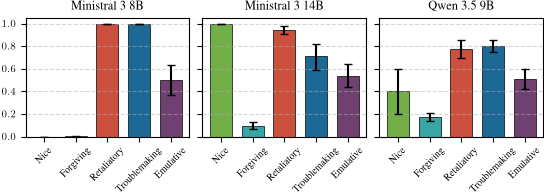


Saved to plots/baselines.pdf


In [62]:
plt.rcParams.update(bundles.iclr2024())
plt.rcParams.update(figsizes.iclr2024(nrows=1, ncols=3, height_to_width_ratio=1.1, rel_width=1))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 3, sharey=True)
for model, ax in zip(models, axes):
    subset = agg_df[(agg_df["model"] == model) & (agg_df["prompt_file"] == baseline_prompt_file)]
    assert len(subset) == 1
    model_metrics = subset.iloc[0]
    model_metrics = [model_metrics[metric] for metric in metrics]
    means = np.array([m[0] for m in model_metrics])
    los = np.array([m[1] for m in model_metrics])
    his = np.array([m[2] for m in model_metrics])
    colors = [metric_colors[metric] for metric in metrics]
    x = np.arange(len(model_metrics))
    bars = ax.bar(x, means, yerr=[means - los, his - means], capsize=3, color=colors,
                      edgecolor="black", linewidth=0.5, width=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels([metric_names[metric] for metric in metrics], rotation=45, ha="center")
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")
    ax.set_title(model_names[model])

plt.savefig("plots/baselines.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/baselines.pdf")

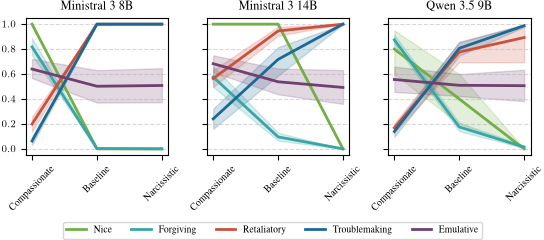


Saved to plots/personas.pdf


In [63]:
plt.rcParams.update(bundles.iclr2024())
plt.rcParams.update(figsizes.iclr2024(nrows=1, ncols=3, height_to_width_ratio=1.2, rel_width=1))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 3, sharey=True)
for model, ax in zip(models, axes):
    for metric in metrics:
        means = []
        los = []
        his = []
        for pf in personas_prompt_files:
            subset = agg_df[
                (agg_df["model"] == model) &
                (agg_df["prompt_file"] == pf)
            ]

            assert len(subset) == 1

            row = subset.iloc[0]
            mean, lo, hi = row[metric]
            means.append(mean)
            los.append(lo)
            his.append(hi)
        means = np.array(means)
        los = np.array(los)
        his = np.array(his)
        x = np.arange(len(personas_prompt_files))
        ax.plot(
            x,
            means,
            label=metric_names[metric],
            color=metric_colors[metric],
            linewidth=2
        )
        ax.fill_between(
            x,
            los,
            his,
            color=metric_colors[metric],
            alpha=0.2
        )
    ax.set_xticks(x)
    ax.set_xticklabels([prompt_file_names[pf] for pf in personas_prompt_files], rotation=45, ha="center")
    ax.set_title(model_names[model])
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(metrics),
    frameon=True,
    bbox_to_anchor=(0.5, -0.12)
)

plt.savefig("plots/personas.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/personas.pdf")

IndexError: single positional indexer is out-of-bounds

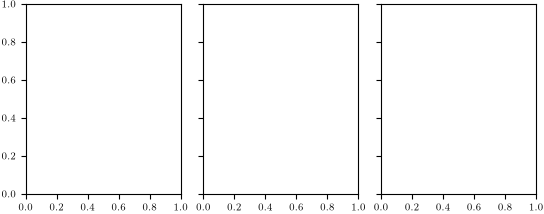

In [ ]:
plt.rcParams.update(bundles.iclr2024())
plt.rcParams.update(figsizes.iclr2024(nrows=1, ncols=3, height_to_width_ratio=1.2, rel_width=1))
plt.rcParams.update({
    "text.latex.preamble": r"\usepackage{times}\usepackage{amsmath}",
    "text.usetex": True,
})

os.makedirs("plots", exist_ok=True)

fig, axes = plt.subplots(1, 3, sharey=True)
for model, ax in zip(models, axes):
    for metric in metrics:
        means = []
        los = []
        his = []
        for pf in tones_prompt_files:
            subset = agg_df[
                (agg_df["model"] == model) &
                (agg_df["prompt_file"] == pf)
            ]

            assert len(subset) == 1

            row = subset.iloc[0]
            mean, lo, hi = row[metric]
            means.append(mean)
            los.append(lo)
            his.append(hi)
        means = np.array(means)
        los = np.array(los)
        his = np.array(his)
        x = np.arange(len(tones_prompt_files))
        ax.plot(
            x,
            means,
            label=metric_names[metric],
            color=metric_colors[metric],
            linewidth=2
        )
        ax.fill_between(
            x,
            los,
            his,
            color=metric_colors[metric],
            alpha=0.2
        )
    ax.set_xticks(x)
    ax.set_xticklabels([prompt_file_names[pf] for pf in tones_prompt_files], rotation=45, ha="center")
    ax.set_title(model_names[model])
    ax.grid(True, linestyle="--", alpha=0.5, axis="y")

handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=len(metrics),
    frameon=True,
    bbox_to_anchor=(0.5, -0.12)
)

plt.savefig("plots/tones.pdf", bbox_inches="tight")
plt.show()
print("\nSaved to plots/tones.pdf")